In [88]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [89]:
df = pd.read_csv("climate_data_2010_2025.csv")

In [90]:
df.head()

,Date,Latitude,Longitude,Max_Temperature,Min_Temperature,Rainfall
0,2010-01-01,8.5,77.5,32.04,22.81,0.0
1,2010-01-01,8.5,78.5,31.11,22.65,0.0
2,2010-01-01,9.5,76.5,31.27,21.50,0.0
3,2010-01-01,9.5,77.5,30.67,21.35,0.0
4,2010-01-01,9.5,78.5,29.44,20.85,0.0


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1929651 entries, 0 to 1929650
Data columns (total 6 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Date             object 
 1   Latitude         float64
 2   Longitude        float64
 3   Max_Temperature  float64
 4   Min_Temperature  float64
 5   Rainfall         float64
dtypes: float64(5), object(1)
memory usage: 88.3+ MB


In [92]:
df.shape

(1929651, 6)

In [93]:
df.describe()

,Latitude,Longitude,Max_Temperature,Min_Temperature,Rainfall
count,1.929651e+06,1.929651e+06,1.929651e+06,1.929651e+06,1.929651e+06
mean,2.360236e+01,7.997014e+01,3.095360e+01,1.905098e+01,3.420983e+00
std,6.021268e+00,6.271866e+00,5.929023e+00,6.540145e+00,1.040221e+01
min,8.500000e+00,6.850000e+01,2.015030e+00,-8.820000e+00,0.000000e+00
25%,1.950000e+01,7.550000e+01,2.810998e+01,1.468000e+01,0.000000e+00
50%,2.450000e+01,7.850000e+01,3.134000e+01,2.087535e+01,0.000000e+00
75%,2.750000e+01,8.350000e+01,3.450275e+01,2.415795e+01,1.693357e+00
max,3.650000e+01,9.750000e+01,4.877099e+01,3.320000e+01,8.069304e+02


In [94]:
df["Date"] = pd.to_datetime(df["Date"])

In [95]:
print(df.shape)
print(df.head())

(1929651, 6)
        Date  Latitude  Longitude  Max_Temperature  Min_Temperature  Rainfall
0 2010-01-01       8.5       77.5            32.04            22.81       0.0
1 2010-01-01       8.5       78.5            31.11            22.65       0.0
2 2010-01-01       9.5       76.5            31.27            21.50       0.0
3 2010-01-01       9.5       77.5            30.67            21.35       0.0
4 2010-01-01       9.5       78.5            29.44            20.85       0.0


In [96]:
df = df.sort_values(["Latitude", "Longitude", "Date"])

In [97]:
df["MaxTemp_Next_Day"] = (
    df.groupby(["Latitude", "Longitude"])["Max_Temperature"]
      .shift(-1))

In [98]:
df["MaxTemp_Lag1"] = (
    df.groupby(["Latitude", "Longitude"])["Max_Temperature"]
      .shift(1))

In [99]:
df = df.dropna()
print(df.shape)
print(df.isnull().sum())

(1928989, 8)
Date                0
Latitude            0
Longitude           0
Max_Temperature     0
Min_Temperature     0
Rainfall            0
MaxTemp_Next_Day    0
MaxTemp_Lag1        0
dtype: int64


In [100]:
df.columns

Index(['Date', 'Latitude', 'Longitude', 'Max_Temperature', 'Min_Temperature',
       'Rainfall', 'MaxTemp_Next_Day', 'MaxTemp_Lag1'],
      dtype='object')

In [101]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Season"] = df["Month"].map({
    12: 0, 1: 0, 2: 0,   
    3: 1, 4: 1, 5: 1,    
    6: 2, 7: 2, 8: 2,    
    9: 3, 10: 3, 11: 3})

In [102]:
corr = df.select_dtypes(include=["number"]).corr()
print(corr)

                  Latitude  Longitude  Max_Temperature  Min_Temperature  \
Latitude          1.000000   0.078156        -0.349133        -0.401202   
Longitude         0.078156   1.000000        -0.087576         0.025437   
Max_Temperature  -0.349133  -0.087576         1.000000         0.821296   
Min_Temperature  -0.401202   0.025437         0.821296         1.000000   
Rainfall         -0.046766   0.097703        -0.074169         0.161152   
MaxTemp_Next_Day -0.349139  -0.087597         0.974690         0.807130   
MaxTemp_Lag1     -0.349135  -0.087543         0.974690         0.830551   
Year              0.001592   0.001938        -0.014278         0.018951   
Month            -0.000011   0.000019        -0.035462         0.100767   
Season           -0.000243   0.000100         0.247913         0.444568   

                  Rainfall  MaxTemp_Next_Day  MaxTemp_Lag1      Year  \
Latitude         -0.046766         -0.349139     -0.349135  0.001592   
Longitude         0.097703    

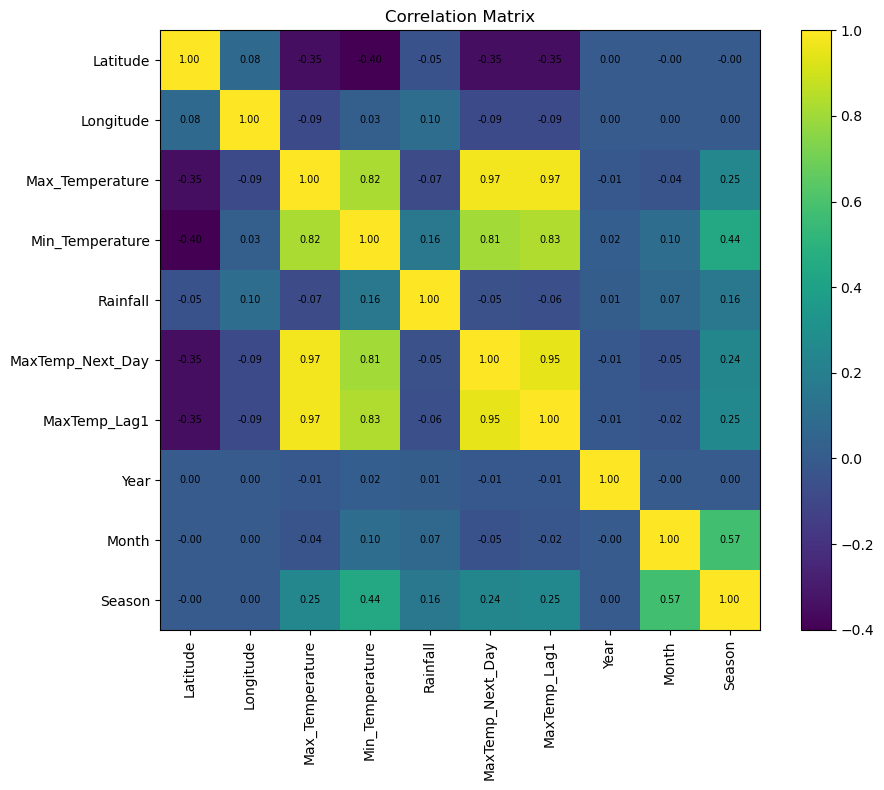

In [103]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7 )
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

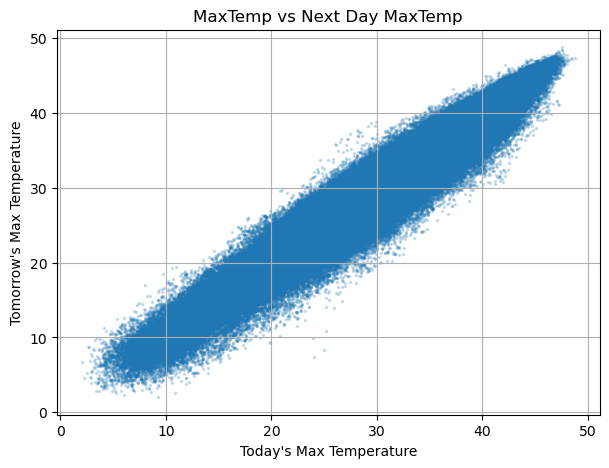

In [104]:
plt.figure(figsize=(7,5))
plt.scatter(
    df["Max_Temperature"],
    df["MaxTemp_Next_Day"],
    s=2,
    alpha=0.2)
plt.xlabel("Today's Max Temperature")
plt.ylabel("Tomorrow's Max Temperature")
plt.title("MaxTemp vs Next Day MaxTemp")
plt.grid(True)
plt.show()

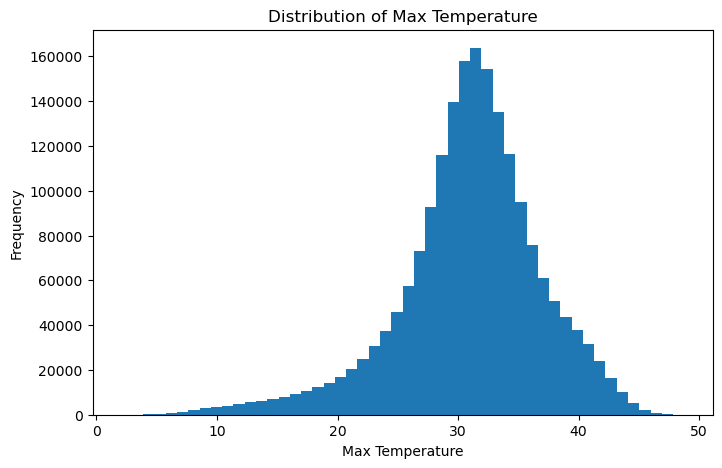

In [105]:
plt.figure(figsize=(8,5))
plt.hist(df["Max_Temperature"], bins=50)
plt.xlabel("Max Temperature")
plt.ylabel("Frequency")
plt.title("Distribution of Max Temperature")
plt.show()

In [106]:
df["Temp_Change"] = df["Max_Temperature"] - df["Min_Temperature"]

In [107]:
max_features = [
    "Latitude",
    "Longitude",
    "Max_Temperature",
    "Min_Temperature",
    "Rainfall",
    "MaxTemp_Lag1",
    "Temp_Change",
    "Year",
    "Month",
    "Season"]
max_target = "MaxTemp_Next_Day"

In [120]:
max_train_df = df[df["Year"] <= 2023]
max_test_df = df[df["Year"] >= 2024]
X_train_max = max_train_df[max_features]
y_train_max = max_train_df[max_target]
X_test_max = max_test_df[max_features]
y_test_max = max_test_df[max_target]

In [121]:
model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

In [122]:
model.fit(X_train_max, y_train_max)

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,8
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = model.predict(X_test_max)
print("MAE :", mean_absolute_error(y_test_max, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_max, y_pred)))
print("R² :", r2_score(y_test_max, y_pred))

MAE : 0.9412741461950015
RMSE: 1.2986703100326158
R² : 0.9473964715958583


In [124]:
pred_df = X_test_max.copy()
pred_df["Actual_MaxTemp"] = y_test_max.values
pred_df["Predicted_MaxTemp"] = y_pred
print(pred_df[["Actual_MaxTemp", "Predicted_MaxTemp"]].head(20))

         Actual_MaxTemp  Predicted_MaxTemp
1687869       32.465076          31.478147
1688200       32.174750          32.398428
1688531       31.948970          32.007776
1688862       31.256693          31.865115
1689193       32.025840          31.283805
1689524       31.692030          31.945064
1689855       31.065640          31.797564
1690186       29.133179          31.342079
1690517       30.967592          29.640850
1690845       32.032925          31.345583
1691176       31.838692          31.931978
1691504       32.429405          31.718759
1691833       32.257760          32.338752
1692164       32.347800          32.133777
1692493       32.136497          32.176127
1692824       32.628586          32.007776
1693155       32.628740          32.477949
1693486       32.254116          32.481315
1693817       31.354172          32.133777
1694148       33.159805          31.332467


Minimum Temperature Prediction

In [113]:
df["MinTemp_Next_Day"] = (
    df.groupby(["Latitude", "Longitude"])["Min_Temperature"]
      .shift(-1))

In [114]:
df["MinTemp_Lag1"] = (
    df.groupby(["Latitude", "Longitude"])["Min_Temperature"]
      .shift(1))

In [115]:
df = df.dropna()
print(df.shape)
print(df.isnull().sum())

(1928327, 14)
Date                0
Latitude            0
Longitude           0
Max_Temperature     0
Min_Temperature     0
Rainfall            0
MaxTemp_Next_Day    0
MaxTemp_Lag1        0
Year                0
Month               0
Season              0
Temp_Change         0
MinTemp_Next_Day    0
MinTemp_Lag1        0
dtype: int64


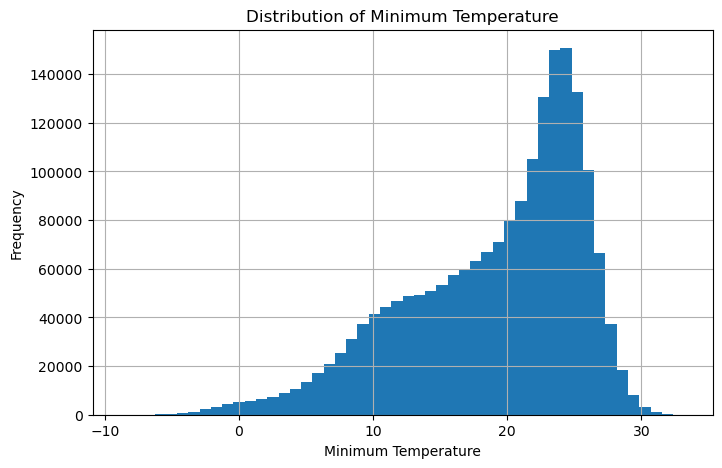

In [116]:
plt.figure(figsize=(8,5))
plt.hist(df["Min_Temperature"], bins=50)
plt.xlabel("Minimum Temperature")
plt.ylabel("Frequency")
plt.title("Distribution of Minimum Temperature")
plt.grid(True)
plt.show()

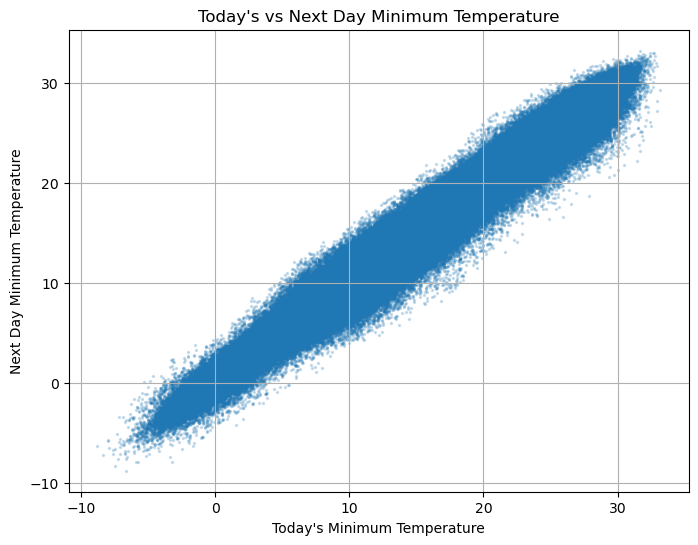

In [117]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Min_Temperature"],
    df["MinTemp_Next_Day"],
    s=2,
    alpha=0.2)
plt.xlabel("Today's Minimum Temperature")
plt.ylabel("Next Day Minimum Temperature")
plt.title("Today's vs Next Day Minimum Temperature")
plt.grid(True)
plt.show()

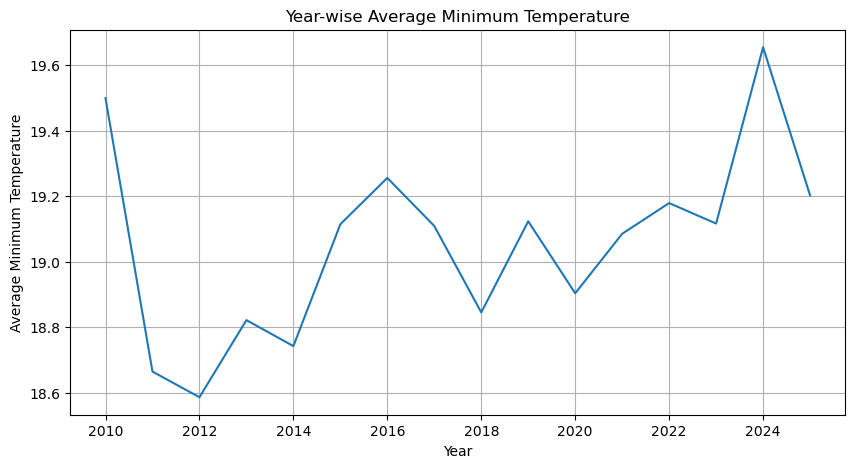

In [118]:
yearly_temp = (
    df.groupby("Year")["Min_Temperature"]
      .mean()
      .reset_index())
plt.figure(figsize=(10,5))
plt.plot(
    yearly_temp["Year"],
    yearly_temp["Min_Temperature"])
plt.xlabel("Year")
plt.ylabel("Average Minimum Temperature")
plt.title("Year-wise Average Minimum Temperature")
plt.grid(True)
plt.show()

In [125]:
features = [
    "Latitude",
    "Longitude",
    "Max_Temperature",
    "Min_Temperature",
    "Rainfall",
    "MinTemp_Lag1",
    "Temp_Change",
    "Year",
    "Month",
    "Season"]
target = "MinTemp_Next_Day"

In [126]:
train_df = df[df["Year"] <= 2023]
test_df = df[df["Year"] >= 2024]
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]
print(X_train.shape)
print(X_test.shape)

(1687207, 10)
(241120, 10)


In [127]:
model_min = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42)

In [128]:
model_min.fit(X_train, y_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,8
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [129]:
y_pred = model_min.predict(X_test)

In [130]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))

MAE : 0.6711054128165345
RMSE: 0.9112515912787071
R² : 0.979374147364088
